In [1]:
pip install opencv-python matplotlib pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import os
import cv2
import matplotlib.pyplot as plt

# SROIE DATASET

In [3]:
sroie_path = r"E:\Projects_AI_ML\docfusion\data\raw\SROIE2019\train\img"

In [4]:
image_paths = []

for file in os.listdir(sroie_path):
    if file.endswith(".jpg"):
        image_paths.append(os.path.join(sroie_path, file))

print("Total images:", len(image_paths))

Total images: 626


(-0.5, 462.5, 1012.5, -0.5)

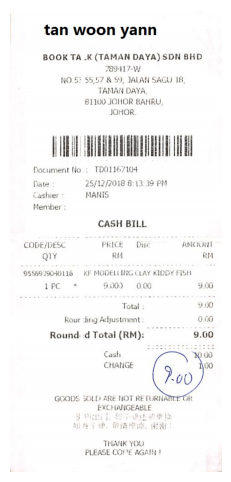

In [5]:
img = cv2.imread(image_paths[0])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.axis("off")

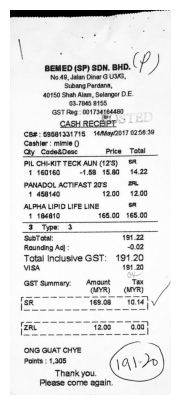

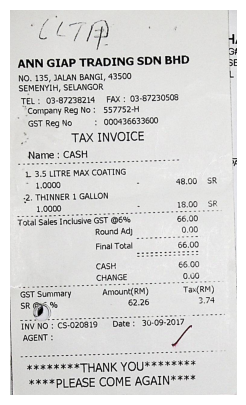

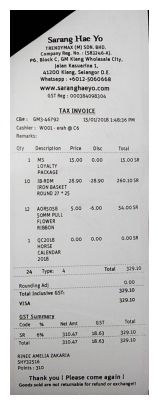

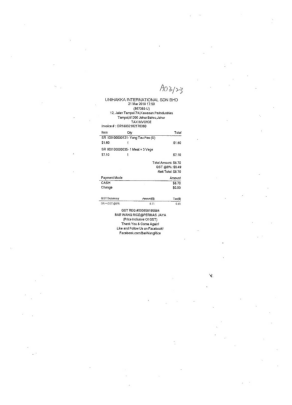

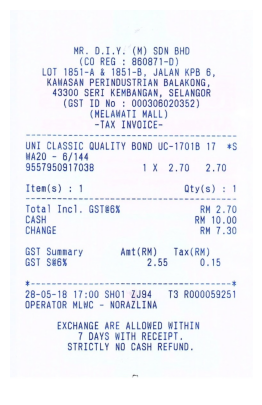

In [6]:
import random

samples = random.sample(image_paths, 5)

for img_path in samples:

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis("off")

# CORD

In [7]:
cord_path = r"E:\Projects_AI_ML\docfusion\data\raw\cord\train\images"

In [8]:
cord_images = []

for file in os.listdir(cord_path):
    if file.endswith(".png") or file.endswith(".jpg"):
        cord_images.append(os.path.join(cord_path, file))

print("Total CORD images:", len(cord_images))

Total CORD images: 800


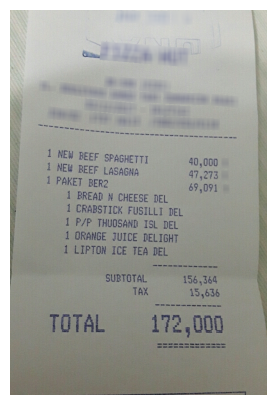

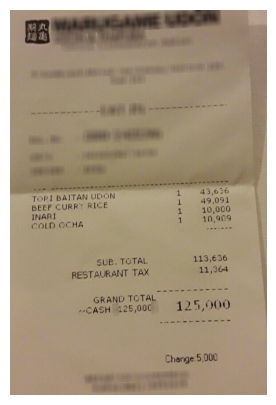

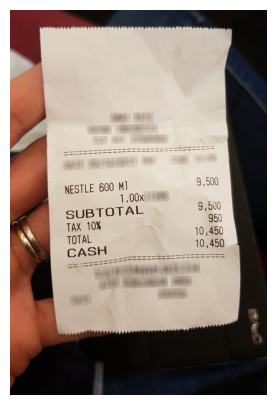

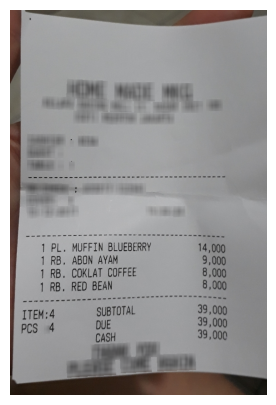

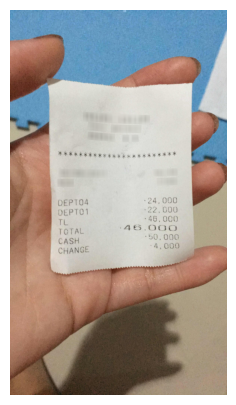

In [9]:
samples = random.sample(cord_images, 5)

for img_path in samples:

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(5,5))
    plt.imshow(img)
    plt.axis("off")

In [10]:
# Dataset Size Analysis

In [11]:
print("SROIE images:", len(image_paths))
print("CORD images:", len(cord_images))

total_docs = len(image_paths) + len(cord_images)

print("Total documents:", total_docs)

SROIE images: 626
CORD images: 800
Total documents: 1426


## Image Resolution Analysis

In [12]:
import pandas as pd

heights = []
widths = []

for img_path in image_paths[:200]:  # sample for speed
    img = cv2.imread(img_path)
    h, w, _ = img.shape
    heights.append(h)
    widths.append(w)

df_size = pd.DataFrame({
    "height": heights,
    "width": widths
})

df_size.head()

,height,width
0,1013,463
1,1004,439
2,949,459
3,933,461
4,1026,463


## Visualize Image Size Distribution

Text(0.5, 1.0, 'Image Height Distribution')

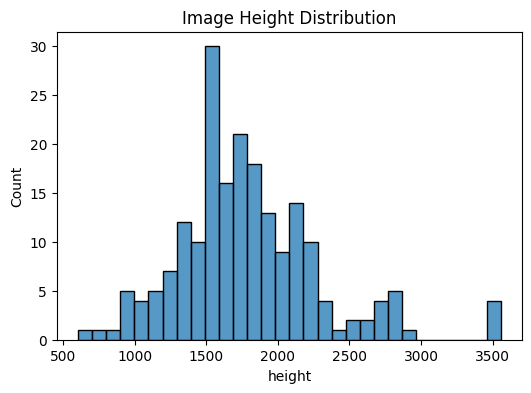

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.histplot(df_size["height"], bins=30)
plt.title("Image Height Distribution")

Text(0.5, 1.0, 'Image Width Distribution')

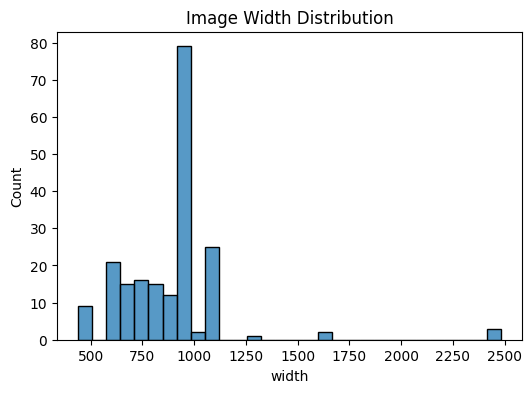

In [14]:
plt.figure(figsize=(6,4))
sns.histplot(df_size["width"], bins=30)
plt.title("Image Width Distribution")

In [15]:
# Aspect Ratio Analysis

Text(0.5, 1.0, 'Receipt Aspect Ratio Distribution')

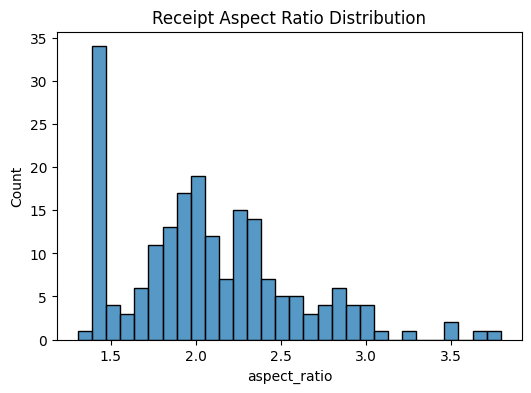

In [16]:
df_size["aspect_ratio"] = df_size["height"] / df_size["width"]

plt.figure(figsize=(6,4))
sns.histplot(df_size["aspect_ratio"], bins=30)
plt.title("Receipt Aspect Ratio Distribution")

### Brightness Analysis , THIS HELPS DETECT dark scans faded receipts AND overexposed images

Text(0.5, 1.0, 'Image Brightness Distribution')

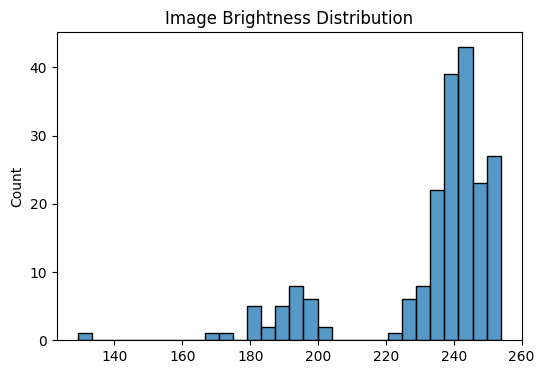

In [17]:
import numpy as np

brightness = []

for img_path in image_paths[:200]:

    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    brightness.append(np.mean(gray))

plt.figure(figsize=(6,4))
sns.histplot(brightness, bins=30)
plt.title("Image Brightness Distribution")

##  Blur Detection - Blurry receipts cause OCR errors

In [18]:
def detect_blur(image_path):

    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    return cv2.Laplacian(gray, cv2.CV_64F).var()

Text(0.5, 1.0, 'Blur Score Distribution')

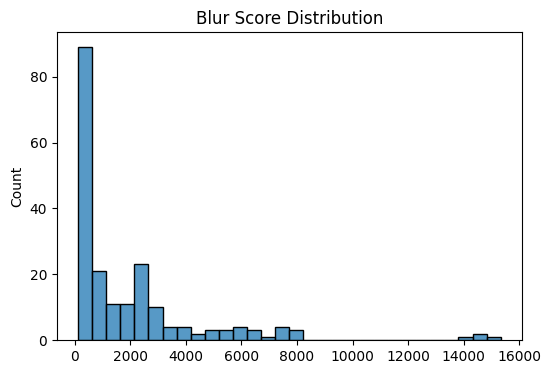

In [19]:
blur_scores = []

for img_path in image_paths[:200]:
    blur_scores.append(detect_blur(img_path))

plt.figure(figsize=(6,4))
sns.histplot(blur_scores, bins=30)
plt.title("Blur Score Distribution")

###  Visualize Extreme Cases - Find very dark receipts

(-0.5, 811.5, 2863.5, -0.5)

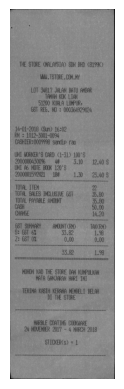

In [20]:
dark_index = np.argmin(brightness)

dark_img = image_paths[dark_index]

img = cv2.imread(dark_img)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")

## Compare SROIE vs CORD

<Axes: xlabel='dataset', ylabel='height'>

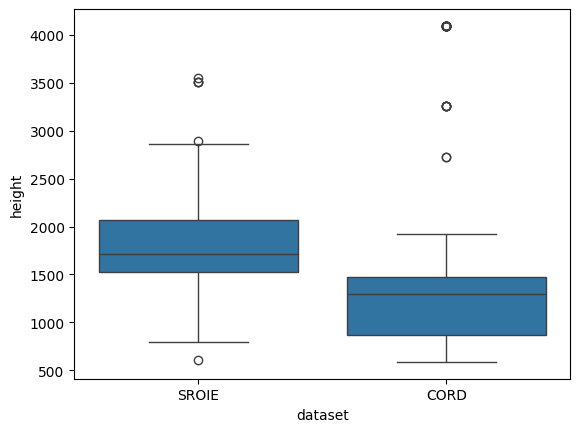

In [21]:
dataset_labels = ["SROIE"] * len(image_paths[:200]) + ["CORD"] * len(cord_images[:200])

heights = []

for img in image_paths[:200]:
    img_data = cv2.imread(img)
    heights.append(img_data.shape[0])

for img in cord_images[:200]:
    img_data = cv2.imread(img)
    heights.append(img_data.shape[0])

df_compare = pd.DataFrame({
    "dataset": dataset_labels,
    "height": heights
})

sns.boxplot(data=df_compare, x="dataset", y="height")

# Level 1 — OCR Extraction + Text EDA


#### Convert receipt images → text

#### Create a text dataset

#### Analyze tokens, prices, dates, vendors

# Install OCR Engine

In [22]:
#Initialize OCR:
from paddleocr import PaddleOCR

ocr = PaddleOCR(lang="en")

Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
C:\Users\sachu\anaconda3\lib\site-packages\paddle\utils\cpp_extension\extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
Creating model: ('PP-LCNet_x1_0_doc_ori', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\sachu\.paddlex\official_models\PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\sachu\.paddlex\official_models\UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None)
Model files already exist. Using cached files. To redownload, please delete the dir

## Run OCR on One Receipt

In [23]:
img_path = image_paths[0]

result = ocr.predict(img_path)

texts = result[0]["rec_texts"]

for t in texts:
    print(t)

tan woon yann
BOOK TA.K (TAMAN DAYA) SDN BHD
789417-W
NO.5: 55,57 & 59, JALAN SAGU 18,
TAMAN DAYA,
81100 JOHOR BAHRU,
JOHOR.
Document No :TD01167104
Date :
25/12/2018 8:13:39 PM
Cashier:
MANIS
Member:
CASH BILL
CODE/DESC
PRICE
Disc
AMOUNT
QTY
RM
RM
9556939040118
KF MODELLING CLAY KIDDY FISH
1 PC
*
9.000
0.00
9.00
Total :
9.00
Rour ding Adjustment:
0.00
Round d Total (RM):
9.00
Cash
10.00
CHANGE
GOODS SOLD ARE NOT RETURNABLE OR
EXCHANGEABLE
9 atrl AMBabatein
onAT1P, 6IAPIRC NIWI
THANK YOU
PLEASE COM'E AGAIN !


In [24]:
result[0]["rec_texts"]

['tan woon yann',
 'BOOK TA.K (TAMAN DAYA) SDN BHD',
 '789417-W',
 'NO.5: 55,57 & 59, JALAN SAGU 18,',
 'TAMAN DAYA,',
 '81100 JOHOR BAHRU,',
 'JOHOR.',
 'Document No :TD01167104',
 'Date :',
 '25/12/2018 8:13:39 PM',
 'Cashier:',
 'MANIS',
 'Member:',
 'CASH BILL',
 'CODE/DESC',
 'PRICE',
 'Disc',
 'AMOUNT',
 'QTY',
 'RM',
 'RM',
 '9556939040118',
 'KF MODELLING CLAY KIDDY FISH',
 '1 PC',
 '*',
 '9.000',
 '0.00',
 '9.00',
 'Total :',
 '9.00',
 'Rour ding Adjustment:',
 '0.00',
 'Round d Total (RM):',
 '9.00',
 'Cash',
 '10.00',
 'CHANGE',
 'GOODS SOLD ARE NOT RETURNABLE OR',
 'EXCHANGEABLE',
 '9 atrl AMBabatein',
 'onAT1P, 6IAPIRC NIWI',
 'THANK YOU',
 "PLEASE COM'E AGAIN !"]

## Show OCR Boxes on Receipt

(-0.5, 462.5, 1012.5, -0.5)

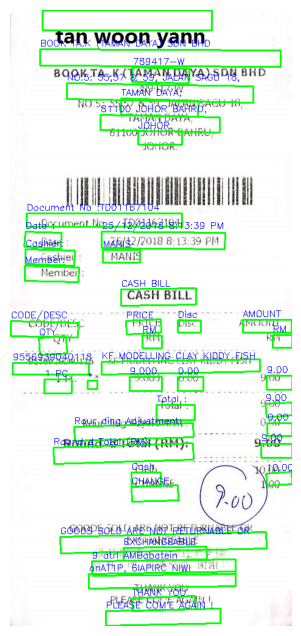

In [25]:
# from paddleocr import draw_ocr
from PIL import Image
import matplotlib.pyplot as plt
import cv2
import matplotlib.pyplot as plt


img = cv2.imread(img_path)

boxes = result[0]["dt_polys"]
texts = result[0]["rec_texts"]

for box, text in zip(boxes, texts):

    pts = box.astype(int)

    cv2.polylines(img, [pts], True, (0,255,0), 2)

    x, y = pts[0]
    cv2.putText(img, text, (x, y-5),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.5, (255,0,0), 1)

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8,8))
plt.imshow(img)
plt.axis("off")

# Save OCR Results Properly

In [26]:
from tqdm import tqdm

ocr_data = []

for img in tqdm(image_paths[:10]):   

    result = ocr.predict(img)

    texts = result[0]["rec_texts"]

    for t in texts:
        ocr_data.append({
            "image": img,
            "text": t
        })

100%|██████████████████████████████████████████████████████████████████████████████████| 10/10 [04:47<00:00, 28.73s/it]


# Convert to DataFrame

In [28]:
import pandas as pd

df = pd.DataFrame(ocr_data)

df.head()

,image,text
0,E:\Projects_AI_ML\docfusion\data\raw\SROIE2019...,tan woon yann
1,E:\Projects_AI_ML\docfusion\data\raw\SROIE2019...,BOOK TA.K (TAMAN DAYA) SDN BHD
2,E:\Projects_AI_ML\docfusion\data\raw\SROIE2019...,789417-W
3,E:\Projects_AI_ML\docfusion\data\raw\SROIE2019...,"NO.5: 55,57 & 59, JALAN SAGU 18,"
4,E:\Projects_AI_ML\docfusion\data\raw\SROIE2019...,"TAMAN DAYA,"


# Clean the Text

In [29]:
import re

def clean_text(text):

    text = text.lower().strip()

    text = re.sub(r'[^a-z0-9./: ]','',text)

    return text

In [30]:
df["clean_text"] = df["text"].apply(clean_text)

# Word Frequency Analysis

In [31]:
from collections import Counter

words = " ".join(df["clean_text"]).split()

Counter(words).most_common(20)

[(':', 34),
 ('1', 29),
 ('total', 25),
 ('rm', 21),
 ('cash', 14),
 ('0.00', 14),
 ('10.00', 12),
 ('gst', 12),
 ('qty', 10),
 ('x', 10),
 ('jalan', 9),
 ('change', 9),
 ('tan', 8),
 ('johor', 8),
 ('invoice', 7),
 ('taman', 6),
 ('sdn', 6),
 ('are', 6),
 ('rounding', 6),
 ('tax', 6)]

# Detect Prices
#### To identify the total amount on receipts, we search for lines containing the word "total".
#### Then we extract numeric values in the format XX.XX.

In [32]:
df["is_total_line"] = df["clean_text"].str.contains("total", na=False)

print(df["is_total_line"].sum())

30


In [33]:
df.loc[df["clean_text"].str.contains("total", na=False), "price"] = \
df["clean_text"].str.extract(r'(\d+\.\d{2})')

In [34]:
df[df["is_total_line"]]

,image,text,clean_text,is_total_line,price
28,E:\Projects_AI_ML\docfusion\data\raw\SROIE2019...,Total :,total :,True,NaN
32,E:\Projects_AI_ML\docfusion\data\raw\SROIE2019...,Round d Total (RM):,round d total rm:,True,NaN
74,E:\Projects_AI_ML\docfusion\data\raw\SROIE2019...,#Total Qty,total qty,True,NaN
76,E:\Projects_AI_ML\docfusion\data\raw\SROIE2019...,TOTALMT..........RM,totalmt..........rm,True,NaN
120,E:\Projects_AI_ML\docfusion\data\raw\SROIE2019...,TOTAL,total,True,NaN
124,E:\Projects_AI_ML\docfusion\data\raw\SROIE2019...,TOTAL ROUNDED,total rounded,True,NaN
165,E:\Projects_AI_ML\docfusion\data\raw\SROIE2019...,Total Qty,total qty,True,NaN
168,E:\Projects_AI_ML\docfusion\data\raw\SROIE2019...,Total Sales (Excluding GST).,total sales excluding gst.,True,NaN
172,E:\Projects_AI_ML\docfusion\data\raw\SROIE2019...,Total GST:,total gst:,True,NaN
176,E:\Projects_AI_ML\docfusion\data\raw\SROIE2019...,Total Sales (inclusiv of GST) :,total sales inclusiv of gst :,True,NaN


In [35]:
print(df[df["is_total_line"]][["image","clean_text"]])

                                                 image  \
28   E:\Projects_AI_ML\docfusion\data\raw\SROIE2019...   
32   E:\Projects_AI_ML\docfusion\data\raw\SROIE2019...   
74   E:\Projects_AI_ML\docfusion\data\raw\SROIE2019...   
76   E:\Projects_AI_ML\docfusion\data\raw\SROIE2019...   
120  E:\Projects_AI_ML\docfusion\data\raw\SROIE2019...   
124  E:\Projects_AI_ML\docfusion\data\raw\SROIE2019...   
165  E:\Projects_AI_ML\docfusion\data\raw\SROIE2019...   
168  E:\Projects_AI_ML\docfusion\data\raw\SROIE2019...   
172  E:\Projects_AI_ML\docfusion\data\raw\SROIE2019...   
176  E:\Projects_AI_ML\docfusion\data\raw\SROIE2019...   
191  E:\Projects_AI_ML\docfusion\data\raw\SROIE2019...   
228  E:\Projects_AI_ML\docfusion\data\raw\SROIE2019...   
232  E:\Projects_AI_ML\docfusion\data\raw\SROIE2019...   
266  E:\Projects_AI_ML\docfusion\data\raw\SROIE2019...   
268  E:\Projects_AI_ML\docfusion\data\raw\SROIE2019...   
351  E:\Projects_AI_ML\docfusion\data\raw\SROIE2019...   
354  E:\Projec

In [36]:
df.loc[df["is_total_line"], "price"] = df["clean_text"].str.extract(r'(\d+\.\d{2})')

In [37]:
print(df[df["price"].notnull()][["clean_text","price"]])

Empty DataFrame
Columns: [clean_text, price]
Index: []


# Detect Dates

In [38]:
df["date"] = df["clean_text"].str.extract(r'(\d{2}/\d{2}/\d{4})')

In [39]:
df[df["date"].notnull()]

,image,text,clean_text,is_total_line,price,date
9,E:\Projects_AI_ML\docfusion\data\raw\SROIE2019...,25/12/2018 8:13:39 PM,25/12/2018 8:13:39 pm,False,NaN,25/12/2018
50,E:\Projects_AI_ML\docfusion\data\raw\SROIE2019...,19/10/2018 20:49:59 #01,19/10/2018 20:49:59 01,False,NaN,19/10/2018
148,E:\Projects_AI_ML\docfusion\data\raw\SROIE2019...,Date 25/12/2018,date 25/12/2018,False,NaN,25/12/2018
254,E:\Projects_AI_ML\docfusion\data\raw\SROIE2019...,09/01/2019 8:01:11 PM,09/01/2019 8:01:11 pm,False,NaN,09/01/2019
290,E:\Projects_AI_ML\docfusion\data\raw\SROIE2019...,Date: 11/01/2019,date: 11/01/2019,False,NaN,11/01/2019
466,E:\Projects_AI_ML\docfusion\data\raw\SROIE2019...,Date: 12/02/2018,date: 12/02/2018,False,NaN,12/02/2018
495,E:\Projects_AI_ML\docfusion\data\raw\SROIE2019...,DRD #50 -REG #19- 18/01/2018 10:27:03,drd 50 reg 19 18/01/2018 10:27:03,False,NaN,18/01/2018


# Detect Vendor


#### Vendor names typically appear near the top of receipts.To identify the vendor, the first three OCR lines are examined andthe longest text string is selected as the vendor candidate.

In [40]:
vendors = df.groupby("image").first()

vendors.head()

,text,clean_text,is_total_line,price,date
image,,,,,
E:\Projects_AI_ML\docfusion\data\raw\SROIE2019\train\img\X00016469612.jpg,tan woon yann,tan woon yann,False,None,25/12/2018
E:\Projects_AI_ML\docfusion\data\raw\SROIE2019\train\img\X00016469619.jpg,tan woon yann,tan woon yann,False,None,19/10/2018
E:\Projects_AI_ML\docfusion\data\raw\SROIE2019\train\img\X00016469620.jpg,tan woon yann,tan woon yann,False,None,None
E:\Projects_AI_ML\docfusion\data\raw\SROIE2019\train\img\X00016469622.jpg,tan woon yann,tan woon yann,False,None,25/12/2018
E:\Projects_AI_ML\docfusion\data\raw\SROIE2019\train\img\X00016469623.jpg,tan woon yann,tan woon yann,False,None,None


In [41]:
df.groupby("image").size().mean()

52.3

In [42]:
vendors = df.groupby("image").first()

In [43]:
vendor_candidates = df.groupby("image").head(3)

vendors = vendor_candidates.groupby("image")["clean_text"].apply(
    lambda x: max(x, key=len)
)

In [44]:
vendors

image
E:\Projects_AI_ML\docfusion\data\raw\SROIE2019\train\img\X00016469612.jpg              book ta.k taman daya sdn bhd
E:\Projects_AI_ML\docfusion\data\raw\SROIE2019\train\img\X00016469619.jpg                     indah gift  home deco
E:\Projects_AI_ML\docfusion\data\raw\SROIE2019\train\img\X00016469620.jpg                   mr d.i.y. johor sdn bhd
E:\Projects_AI_ML\docfusion\data\raw\SROIE2019\train\img\X00016469622.jpg                       yongfatt enterprise
E:\Projects_AI_ML\docfusion\data\raw\SROIE2019\train\img\X00016469623.jpg                       mr d.i.y. m sdn bhd
E:\Projects_AI_ML\docfusion\data\raw\SROIE2019\train\img\X00016469669.jpg                   no.24 jalan harmoni 3/2
E:\Projects_AI_ML\docfusion\data\raw\SROIE2019\train\img\X00016469672.jpg            soon huat machinery enterprise
E:\Projects_AI_ML\docfusion\data\raw\SROIE2019\train\img\X00016469676.jpg    s.h.h. motor  sungai rengit  sdn. bhd.
E:\Projects_AI_ML\docfusion\data\raw\SROIE2019\train\img\X51005200

In [45]:
df["dataset"] = df["image"].apply(
    lambda x: "sroie" if "SROIE2019" in x else "cord"
)

In [46]:
df["dataset"].unique()

array(['sroie'], dtype=object)

## Load CORD Images

In [47]:
cord_path = r"E:\Projects_AI_ML\docfusion\data\raw\cord\train\images"

cord_images = []

import os

for f in os.listdir(cord_path):
    if f.endswith(".png") or f.endswith(".jpg"):
        cord_images.append(os.path.join(cord_path, f))

print("CORD images:", len(cord_images))

CORD images: 800


 ## Combine Both Datasets

In [48]:
all_images = image_paths + cord_images

print("Total images:", len(all_images))

Total images: 1426


## Run OCR on Combined Dataset

In [49]:
for img in all_images:
    print(img)

E:\Projects_AI_ML\docfusion\data\raw\SROIE2019\train\img\X00016469612.jpg
E:\Projects_AI_ML\docfusion\data\raw\SROIE2019\train\img\X00016469619.jpg
E:\Projects_AI_ML\docfusion\data\raw\SROIE2019\train\img\X00016469620.jpg
E:\Projects_AI_ML\docfusion\data\raw\SROIE2019\train\img\X00016469622.jpg
E:\Projects_AI_ML\docfusion\data\raw\SROIE2019\train\img\X00016469623.jpg
E:\Projects_AI_ML\docfusion\data\raw\SROIE2019\train\img\X00016469669.jpg
E:\Projects_AI_ML\docfusion\data\raw\SROIE2019\train\img\X00016469672.jpg
E:\Projects_AI_ML\docfusion\data\raw\SROIE2019\train\img\X00016469676.jpg
E:\Projects_AI_ML\docfusion\data\raw\SROIE2019\train\img\X51005200938.jpg
E:\Projects_AI_ML\docfusion\data\raw\SROIE2019\train\img\X51005230617.jpg
E:\Projects_AI_ML\docfusion\data\raw\SROIE2019\train\img\X51005255805.jpg
E:\Projects_AI_ML\docfusion\data\raw\SROIE2019\train\img\X51005268200.jpg
E:\Projects_AI_ML\docfusion\data\raw\SROIE2019\train\img\X51005268262.jpg
E:\Projects_AI_ML\docfusion\data\raw\S

In [50]:
df["dataset"] = df["image"].apply(
    lambda x: "sroie" if "SROIE2019" in x else "cord"
)

In [51]:
df["dataset"].unique()

array(['sroie'], dtype=object)

In [52]:
len(cord_images)

800

In [54]:
import cv2
from tqdm import tqdm

ocr_data = []

sample_images = image_paths[:15] + cord_images[:15]

for img in tqdm(sample_images):

    try:
        image = cv2.imread(img)

        if image is None:
            continue

        result = ocr.predict(image)

        texts = result[0].get("rec_texts", [])

        for t in texts:
            ocr_data.append({
                "image": img,
                "text": t
            })

    except Exception as e:
        print("Failed:", img)

 70%|█████████████████████████████████████████████████████████▍                        | 21/30 [16:01<13:55, 92.82s/it]

Failed: E:\Projects_AI_ML\docfusion\data\raw\cord\train\images\0005.png


 97%|███████████████████████████████████████████████████████████████████████████████▎  | 29/30 [23:15<01:29, 89.80s/it]

Failed: E:\Projects_AI_ML\docfusion\data\raw\cord\train\images\0013.png


100%|██████████████████████████████████████████████████████████████████████████████████| 30/30 [23:35<00:00, 47.18s/it]


In [55]:
df = pd.DataFrame(ocr_data)

In [56]:
df["dataset"] = df["image"].apply(
    lambda x: "sroie" if "SROIE2019" in x else "cord"
)

df["dataset"].unique()

array(['sroie', 'cord'], dtype=object)

## Convert OCR Results to DataFrame

In [57]:
import pandas as pd

df = pd.DataFrame(ocr_data)

df.head()

,image,text
0,E:\Projects_AI_ML\docfusion\data\raw\SROIE2019...,tan woon yann
1,E:\Projects_AI_ML\docfusion\data\raw\SROIE2019...,BOOK TA.K (TAMAN DAYA) SDN BHD
2,E:\Projects_AI_ML\docfusion\data\raw\SROIE2019...,789417-W
3,E:\Projects_AI_ML\docfusion\data\raw\SROIE2019...,"NO.5: 55,57 & 59, JALAN SAGU 18,"
4,E:\Projects_AI_ML\docfusion\data\raw\SROIE2019...,"TAMAN DAYA,"


### Clean OCR Text

In [58]:
import re

def clean_text(text):
    text = text.lower().strip()
    text = re.sub(r'[^a-z0-9./: ]', '', text)
    return text

df["clean_text"] = df["text"].apply(clean_text)

## Detect Dataset Source

In [59]:
df["dataset"] = df["image"].apply(
    lambda x: "sroie" if "SROIE2019" in x else "cord"
)

df["dataset"].unique()

array(['sroie', 'cord'], dtype=object)

## Detect Total Price

In [60]:
df["is_total_line"] = df["clean_text"].str.contains("total", na=False)

df.loc[df["is_total_line"], "price"] = df["clean_text"].str.extract(r'(\d+\.\d{2})')
df["is_total_line"]


0       False
1       False
2       False
3       False
4       False
        ...  
1162    False
1163    False
1164    False
1165    False
1166    False
Name: is_total_line, Length: 1167, dtype: bool

## Detect Date

In [61]:
df["date"] = df["clean_text"].str.extract(r'(\d{2}[/-]\d{2}[/-]\d{2,4})')
df["date"]

0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
       ... 
1162    NaN
1163    NaN
1164    NaN
1165    NaN
1166    NaN
Name: date, Length: 1167, dtype: object

## Detect Vendor

In [62]:
vendor_candidates = df.groupby("image").head(3)

vendors = vendor_candidates.groupby("image")["clean_text"].apply(
    lambda x: max(x, key=len)
)

vendors.head()

image
E:\Projects_AI_ML\docfusion\data\raw\SROIE2019\train\img\X00016469612.jpg    book ta.k taman daya sdn bhd
E:\Projects_AI_ML\docfusion\data\raw\SROIE2019\train\img\X00016469619.jpg           indah gift  home deco
E:\Projects_AI_ML\docfusion\data\raw\SROIE2019\train\img\X00016469620.jpg         mr d.i.y. johor sdn bhd
E:\Projects_AI_ML\docfusion\data\raw\SROIE2019\train\img\X00016469622.jpg             yongfatt enterprise
E:\Projects_AI_ML\docfusion\data\raw\SROIE2019\train\img\X00016469623.jpg             mr d.i.y. m sdn bhd
Name: clean_text, dtype: object

In [63]:
print("Total rows:", len(df))
print("Total receipts:", df["image"].nunique())
print("Average OCR lines per receipt:", df.groupby("image").size().mean())

Total rows: 1167
Total receipts: 28
Average OCR lines per receipt: 41.67857142857143


In [64]:
df.to_csv("ocr_dataset.csv", index=False)